<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# **Hands-on practice lab: Model Development**

Estimated time needed: **45** minutes

In this lab, you will use the skills acquired in throughout the module, and use linear regression principles to create a model that predicts the Price of the laptop, based on one or more attributes of the dataset.


# Objectives

After completing this lab you will be able to:

 - Use Linear Regression in one variable to fit the parameters to a model
 - Use Linear Regression in multiple variables to fit the parameters to a model
 - Use Polynomial Regression in single variable tofit the parameters to a model
 - Create a pipeline for performing linear regression using multiple features in polynomial scaling
 - Evaluate the performance of different forms of regression on basis of MSE and R^2 parameters


# Setup


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### Importing Required Libraries

_We recommend you import all required libraries in one place (here):_


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 
%matplotlib inline

We put the file path along with a quotation mark so that pandas will read the file into a dataframe from that address. The file path can be either an URL or your local file address.


In [4]:
path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

Load the dataset into a pandas dataframe


In [5]:
df = pd.read_csv(path, header=0)

In [6]:
# show the first 5 rows using dataframe.head() method
print("The first 5 rows of the dataframe") 
df.head(5)

The first 5 rows of the dataframe


,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


# Task 1 : Single Linear Regression

You have learnt that "CPU_frequency" is the parameter with the lowest p-value among the different features of the dataset. Create a single feature Linear Regression model that fits the pair of "CPU_frequency" and "Price" to find the model for prediction.


In [7]:
# Write your code below and press Shift+Enter to execute 
# LinearRegression() creates an empty model object, ready to be trained
lm = LinearRegression()

# x is the input feature (CPU_frequency) — double brackets [[ ]] to keep it 2D (required by sklearn)
x = df[['CPU_frequency']]

# y is the target variable (Price) — single brackets [ ] since 1D is fine for output
y = df['Price']

# fit() trains the model by learning the relationship between CPU_frequency and Price
# it figures out the best slope and intercept for the line: Price = slope * CPU_frequency + intercept
lm.fit(x, y)

# predict() plugs each CPU_frequency value into the learned formula and returns predicted prices
# ythat is a NumPy array of 238 predicted price values, one for each row in x
yhat = lm.predict(x)

<details>
    <summary>Click here for Solution</summary>

```python
lm = LinearRegression()

X = df[['CPU_frequency']]
Y = df['Price']

lm.fit(X,Y)

Yhat=lm.predict(X)
```

</details>


Generate the Distribution plot for the predicted values and that of the actual values. How well did the model perform?


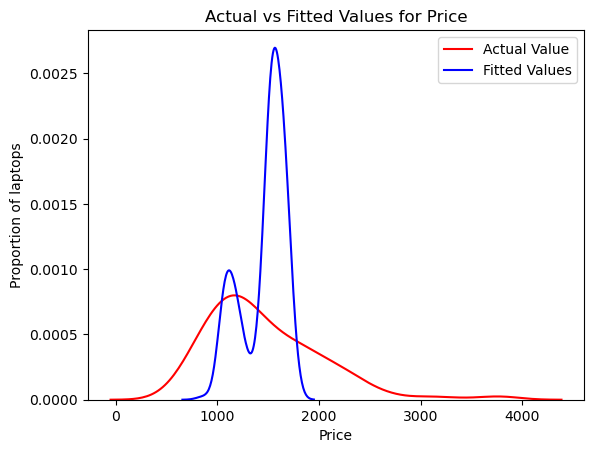

In [8]:
# Write your code below and press Shift+Enter to execute 
# Plot the distribution of actual Price values from the dataset
# hist=False → only show smooth KDE curve, no histogram bars
# color="r" → red curve for actual values
# label="Actual Value" → name for the legend
# ax1 stores the plot object so the next plot can be drawn on the same graph
ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")

# Plot the distribution of predicted Price values (yhat) on the same graph
# hist=False → only smooth curve, no bars
# color="b" → blue curve for predicted values
# label="Fitted Values" → name for the legend
# ax=ax1 → draws this curve on the same axes as the first plot so both appear together
sns.distplot(yhat, hist=False, color="b", label="Fitted Values", ax=ax1)

# Set the title of the graph
plt.title('Actual vs Fitted Values for Price')

# Label the X-axis as Price
plt.xlabel('Price')

# Label the Y-axis as Proportion of laptops
# this represents how densely the prices are distributed at each point
plt.ylabel('Proportion of laptops')

# Add a legend to differentiate the two curves
# red curve = Actual Value, blue curve = Predicted Value
plt.legend()

# Display the final plot
# without this line, the graph may not render in some environments
plt.show()

<details>
    <summary>Click here for Solution</summary>

```python
ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")

# Create a distribution plot for predicted values
sns.distplot(Yhat, hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.legend(['Actual Value', 'Predicted Value'])
plt.show()
```

</details>


Evaluate the Mean Squared Error and R^2 score values for the model. 


In [9]:
# Write your code below and press Shift+Enter to execute 
mse_slr = mean_squared_error(df['Price'],yhat)
r2_score_slr = lm.score(x,y)
print('The R-square for Linear Regression is : ',r2_score_slr)
print('The mean square error of price and predicted value is : ',mse_slr)
# R² Score interpretation:
# 1.0        → Perfect model, predicted values exactly match actual values
# 0.8 - 1.0  → Very good model
# 0.5 - 0.8  → Moderate model
# 0.0 - 0.5  → Poor model
# 0.0        → Model is not capturing any pattern at all
# Negative   → Model is performing worse than just predicting the average

The R-square for Linear Regression is :  0.1344436321024326
The mean square error of price and predicted value is :  284583.4405868629


<details>
    <summary>Click here for Solution</summary>

```python
mse_slr = mean_squared_error(df['Price'], Yhat)
r2_score_slr = lm.score(X, Y)
print('The R-square for Linear Regression is: ', r2_score_slr)
print('The mean square error of price and predicted value is: ', mse_slr)
```

</details>


# Task 2 - Multiple Linear Regression
The parameters which have a low enough p-value so as to indicate strong relationship with the 'Price' value are 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU' and 'Category'. Use all these variables to create a Multiple Linear Regression system. 


In [10]:
# Write your code below and press Shift+Enter to execute 
lm1 = LinearRegression()
z = df[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU' , 'Category']]
lm1.fit(z,y)
yhat1 = lm1.predict(z)

<details>
    <summary>Click here for Solution</summary>

```python
lm1 = LinearRegression()
Z = df[['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']]
lm1.fit(Z,Y)
Y_hat = lm1.predict(Z)
```

</details>


Plot the Distribution graph of the predicted values as well as the Actual values


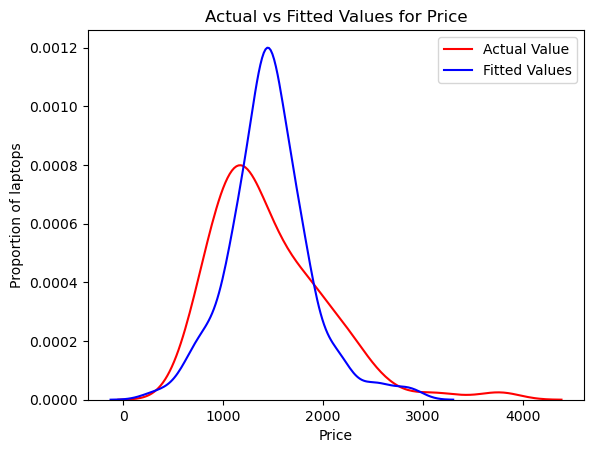

In [11]:
# Write your code below and press Shift+Enter to execute 
# Plot the distribution of actual Price values from the dataset
# hist=False → only show smooth KDE curve, no histogram bars
# color="r" → red curve for actual values
# label="Actual Value" → name for the legend
# ax1 stores the plot object so the next plot can be drawn on the same graph
ax2 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")

# Plot the distribution of predicted Price values (yhat) on the same graph
# hist=False → only smooth curve, no bars
# color="b" → blue curve for predicted values
# label="Fitted Values" → name for the legend
# ax=ax1 → draws this curve on the same axes as the first plot so both appear together
sns.distplot(yhat1, hist=False, color="b", label="Fitted Values", ax=ax2)

# Set the title of the graph
plt.title('Actual vs Fitted Values for Price')

# Label the X-axis as Price
plt.xlabel('Price')

# Label the Y-axis as Proportion of laptops
# this represents how densely the prices are distributed at each point
plt.ylabel('Proportion of laptops')

# Add a legend to differentiate the two curves
# red curve = Actual Value, blue curve = Predicted Value
plt.legend()

# Display the final plot
# without this line, the graph may not render in some environments
plt.show()

<details>
    <summary>Click here for Solution</summary>

```python
ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_hat, hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')

```

</details>


Find the R^2 score and the MSE value for this fit. Is this better or worst than the performance of Single Linear Regression?


In [12]:
# Write your code below and press Shift+Enter to execute
mse_mlr = mean_squared_error(df['Price'],yhat1)
r2_score_mlr = lm1.score(z,y)
print('The R-square for Linear Regression is : ',r2_score_mlr)
print('The mean square error of price and predicted value is : ',mse_mlr)
# R² Score interpretation:
# 1.0        → Perfect model, predicted values exactly match actual values
# 0.8 - 1.0  → Very good model
# 0.5 - 0.8  → Moderate model
# 0.0 - 0.5  → Poor model
# 0.0        → Model is not capturing any pattern at all
# Negative   → Model is performing worse than just predicting the average

The R-square for Linear Regression is :  0.5082509055187374
The mean square error of price and predicted value is :  161680.5726389311


<details>
    <summary>Click here for Solution</summary>

```python
ax2 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_hat, hist=False, color="b", label="Fitted Values" , ax=ax2)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
```

</details>


# Task 3 - Polynomial Regression
Use the variable "CPU_frequency" to create Polynomial features. Try this for 3 different values of polynomial degrees. Remember that polynomial fits are done using `numpy.polyfit`. 


In [14]:
#  Write your code below and press Shift+Enter to execute
# x was originally a 2D pandas dataframe with shape (238, 1)
# to_numpy() converts it from pandas dataframe to numpy array
# flatten() converts it from 2D array (238, 1) to 1D array (238,)
# this is necessary because numpy.polyfit requires 1D input
x = x.to_numpy().flatten()

# np.polyfit(x, y, 1) fits a degree 1 polynomial (straight line) through the data
# it finds the best slope and intercept for: Price = b0 + b1*CPU_frequency
# f1 stores the coefficients of the polynomial — [slope, intercept]
f1 = np.polyfit(x, y, 1)

# np.poly1d(f1) converts the coefficients f1 into a callable function
# p1 is now a function that you can call like p1(x) to get predicted values
# similar to lm.predict(x) in linear regression
p1 = np.poly1d(f1)

# np.polyfit(x, y, 3) fits a degree 3 polynomial (S shaped curve) through the data
# it finds the best coefficients for: Price = b0 + b1*x + b2*x² + b3*x³
# f3 stores the 4 coefficients of the polynomial — [b3, b2, b1, b0]
# degree 3 captures more complex patterns than degree 1
f3 = np.polyfit(x, y, 3)

# np.poly1d(f3) converts the coefficients f3 into a callable function
# p3 is now a function that you can call like p3(x) to get predicted values
p3 = np.poly1d(f3)

# np.polyfit(x, y, 5) fits a degree 5 polynomial (complex S shaped curve) through the data
# it finds the best coefficients for: Price = b0 + b1*x + b2*x² + b3*x³ + b4*x⁴ + b5*x⁵
# f5 stores the 6 coefficients of the polynomial — [b5, b4, b3, b2, b1, b0]
# degree 5 captures even more complex patterns than degree 3
f5 = np.polyfit(x, y, 5)

# np.poly1d(f5) converts the coefficients f5 into a callable function
# p5 is now a function that you can call like p5(x) to get predicted values
p5 = np.poly1d(f5)

<details>
    <summary>Click here for Solution</summary>

```python
X = X.to_numpy().flatten()
f1 = np.polyfit(X, Y, 1)
p1 = np.poly1d(f1)

f3 = np.polyfit(X, Y, 3)
p3 = np.poly1d(f3)

f5 = np.polyfit(X, Y, 5)
p5 = np.poly1d(f5)
```

</details>


Plot the regression output against the actual data points to note how the data fits in each case. To plot the polynomial response over the actual data points, you have the function shown below.


In [17]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(independent_variable.min(),independent_variable.max(),100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title(f'Polynomial Fit for Price ~ {Name}')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of laptops')
    plt.show()

Call this function for the 3 models created and get the required graphs.


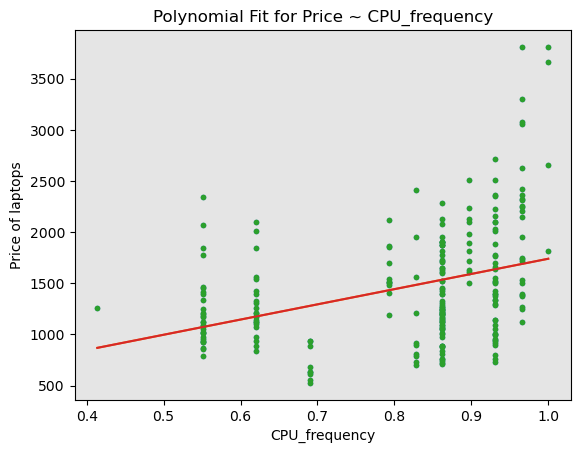

In [18]:
#  Write your code below and press Shift+Enter to execute
# Call for function of degree 1
PlotPolly(p1,x,y,'CPU_frequency')

<details>
    <summary>Click here for Solution</summary>
    
```python
PlotPolly(p1, X, Y, 'CPU_frequency')
```

</details>


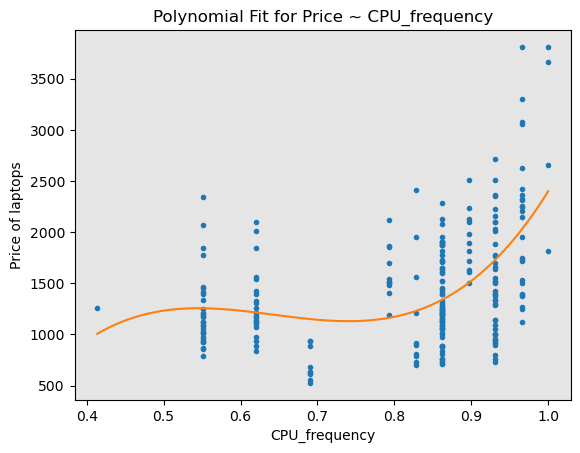

In [19]:
#  Write your code below and press Shift+Enter to execute
# Call for function of degree 3
PlotPolly(p3,x,y,'CPU_frequency')

<details>
    <summary>Click here for Solution</summary>
    
```python
PlotPolly(p3, X, Y, 'CPU_frequency')
```

</details>


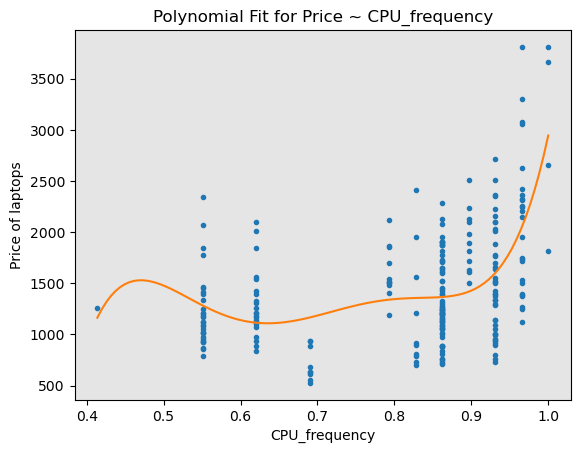

In [20]:
#  Write your code below and press Shift+Enter to execute
# Call for function of degree 5
PlotPolly(p5,x,y,'CPU_frequency')

<details>
    <summary>Click here for Solution</summary>
    
```python
PlotPolly(p5, X, Y, 'CPU_frequency')
```

</details>


Also, calculate the R^2 and MSE values for these fits. For polynomial functions, the function sklearn.metrics.r2_score will be used to calculate R^2 values.


In [21]:
#  Write your code below and press Shift+Enter to execute
r_sq1 = r2_score(y,p1(x))
print('R-square value of 1st degree polynomial is : ',r_sq1)
print('MSE value for 1st degree polynomial is : ',mean_squared_error(y,p1(x)))

r_sq3 = r2_score(y,p3(x))
print('R-square value of 1st degree polynomial is : ',r_sq3)
print('MSE value for 1st degree polynomial is : ',mean_squared_error(y,p3(x)))

r_sq5 = r2_score(y,p5(x))
print('R-square value of 1st degree polynomial is : ',r_sq5)
print('MSE value for 1st degree polynomial is : ',mean_squared_error(y,p5(x)))



R-square value of 1st degree polynomial is :  0.1344436321024326
MSE value for 1st degree polynomial is :  284583.4405868629
R-square value of 1st degree polynomial is :  0.2669264079653094
MSE value for 1st degree polynomial is :  241024.86303848823
R-square value of 1st degree polynomial is :  0.3030822706442371
MSE value for 1st degree polynomial is :  229137.29548058534


<details>
    <summary>Click here for Solution</summary>
    
```python
r_squared_1 = r2_score(Y, p1(X))
print('The R-square value for 1st degree polynomial is: ', r_squared_1)
print('The MSE value for 1st degree polynomial is: ', mean_squared_error(Y,p1(X)))
r_squared_3 = r2_score(Y, p3(X))
print('The R-square value for 3rd degree polynomial is: ', r_squared_3)
print('The MSE value for 3rd degree polynomial is: ', mean_squared_error(Y,p3(X)))
r_squared_5 = r2_score(Y, p5(X))
print('The R-square value for 5th degree polynomial is: ', r_squared_5)
print('The MSE value for 5th degree polynomial is: ', mean_squared_error(Y,p5(X)))
```

</details>


# Task 4 - Pipeline
Create a pipeline that performs parameter scaling, Polynomial Feature generation and Linear regression. Use the set of multiple features as before to create this pipeline. 


In [24]:
#  Write your code below and press Shift+Enter to execute
# A pipeline chains multiple steps together in a sequence
# so the output of each step automatically becomes the input of the next step
# here we are combining 3 steps:
# Step 1 - StandardScaler  : scales the features to have mean=0 and standard deviation=1
# Step 2 - PolynomialFeatures : generates polynomial features from the scaled features
# Step 3 - LinearRegression : fits a linear regression model on the polynomial features

Input = [
    ('scale', StandardScaler()),           # Step 1 - scale the features first
                                           # this is important because features like RAM_GB and 
                                           # Storage_GB_SSD have very different ranges
                                           # scaling brings them all to the same scale

    ('polynomial', PolynomialFeatures(include_bias=False)),  # Step 2 - generate polynomial features
                                                             # include_bias=False means do not add
                                                             # an extra column of 1s (bias term)
                                                             # since LinearRegression handles that automatically

    ('model', LinearRegression())          # Step 3 - fit linear regression on the polynomial features
]

# Pipeline() takes the list of steps and chains them together
pipe = Pipeline(Input)

# z contains all 7 features — CPU_frequency, RAM_GB, Storage_GB_SSD, CPU_core, OS, GPU, Category
# converting z to float because StandardScaler requires numeric float values
z = z.astype(float)

# fit() trains the entire pipeline in one go
# internally it:
# 1. scales z using StandardScaler
# 2. generates polynomial features from scaled z
# 3. fits linear regression on those polynomial features
pipe.fit(z, y)

# predict() passes z through all 3 steps of the pipeline automatically
# and returns the predicted price values
# ypipe is a numpy array of predicted prices, one for each row in z
ypipe = pipe.predict(z)

<details>
    <summary>Click here for Solution</summary>
    
```python
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]
pipe=Pipeline(Input)
Z = Z.astype(float)
pipe.fit(Z,Y)
ypipe=pipe.predict(Z)
```

</details>


Evaluate the MSE and R^2 values for the this predicted output.


In [25]:
#  Write your code below and press Shift+Enter to execute
print('MSE : ', mean_squared_error(y,ypipe))
print('R^2 : ',r2_score(y,ypipe))

MSE :  120595.86128028373
R^2 :  0.6332094535859658


<details>
    <summary>Click here for Solution</summary>
    
```python
print('MSE for multi-variable polynomial pipeline is: ', mean_squared_error(Y, ypipe))
print('R^2 for multi-variable polynomial pipeline is: ', r2_score(Y, ypipe))

```

</details>


You should now have seen that the values of R^2 increase as we go from Single Linear Regression to Multiple Linear Regression. Further, if we go for multiple linear regression extended with polynomial features, we get an even better R^2 value.


# Congratulations! You have completed the lab


## Authors


[Abhishek Gagneja](https://www.coursera.org/instructor/~129186572)

[Vicky Kuo](https://author.skills.network/instructors/vicky_kuo)


### Copyright ©IBM Corporation. All rights reserved.


<!--## Change Log


<!--|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-09-16|0.1|Abhishek Gagneja|Initial Version Created|
|2023-09-19|0.2|Vicky Kuo|Reviewed and Revised|--!>
